# DeeplyGrad Part 3: Building a Transformer from Scratch

In [Part 1](https://mandliya.github.io/blog/2026/building-an-autograd-engine-from-scratch-with-cupy-part-1-tensor-and-backpropagation/) we built a `Tensor` class with full backpropagation support. This gave us the foundation of automatic differentiation. In [Part 2](https://mandliya.github.io/blog/2026/deeplygrad-part-2-teaching-our-autograd-to-classify-mnist-digits/) we added `Module`, activations, losses, and an optimizer to the library, then trained an MLP to classify MNIST digits with high accuracy.

Now, we build the thing this whole series has been building toward: a **decoder-only transfomer** (GPT-style). We will implement every component of the transformer from RoPE (rotary positione embeddings), layer normalization, multi-head causal self-attention, and the feed-forward network and then wire them into a full language model and train it on tiny-shakespeare.

The remarkable thing is that entire transformer is composed from the ~15 primitive tensor ops we built in Part 1(add, mul, matmul, exp, pow, sum, mean, reshape, transpose, indexing..). Autograd handles all the gradient computation automatically.

> Code for this series is available on [GitHub](https://github.com/mandliya/simplygrad)

## Setup: Clone the repo and install

In [1]:
!git clone https://github.com/mandliya/simplygrad.git
%cd simplygrad
!pip install -e . -q

fatal: destination path 'simplygrad' already exists and is not an empty directory.
/content/simplygrad
  Preparing metadata (setup.py) ... done


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from deeplygrad import xp, BACKEND_NAME
from deeplygrad.tensor import Tensor, cat
from deeplygrad.nn import Module, Linear, GELU, Softmax, CrossEntropyLoss
from deeplygrad.optim import Adam
from deeplygrad.backend import xp

print(f"Backend: {BACKEND_NAME}")

Backend: cupy


## The Decoder-Only Transformer Architecture

Before we dive into code, let's understand what we're building. The "decoder-only" transformer is the architecture behind GPT-2, GPT-3, GPT-4, LLaMA, and most modern large language models. It's called "decoder-only" because it uses only the decoder half of the original encoder-decoder transformer from "Attention Is All You Need" (Vaswani et al., 2017).

The architecture is surprisingly simple:

```mermaid
graph TB
    input["Token IDs<br/>(batch, seq_len)"] --> emb["Token Embedding"]
    emb --> block1["Transformer Block 1"]
    block1 --> block2["Transformer Block 2"]
    block2 --> dots["⋮"]
    dots --> blockN["Transformer Block N"]
    blockN --> lnf["Final LayerNorm"]
    lnf --> head["Linear Projection<br/>(d_model → vocab_size)"]
    head --> logits["Logits → next token prediction"]

    style input fill:#4A90D9,stroke:#2C5F8A,color:#fff,stroke-width:2px
    style emb fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style block1 fill:#FFB74D,stroke:#F57C00,color:#333,stroke-width:2px
    style block2 fill:#FFB74D,stroke:#F57C00,color:#333,stroke-width:2px
    style blockN fill:#FFB74D,stroke:#F57C00,color:#333,stroke-width:2px
    style lnf fill:#FFB74D,stroke:#F57C00,color:#333,stroke-width:2px
    style head fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style logits fill:#FF7043,stroke:#D84315,color:#fff,stroke-width:2px
    style dots fill:none,stroke:none,color:#333
```

Each component has a one clear job:
1. **Token Embedding** converts token IDs into dense vectors.
2. **Transformer Blocks** are stacked N times. Each block applies self-attention (letting tokens communicate) followed by an MLP (letting each token think independently), with layer normalization and residual connections.
3. **Final LayerNorm** normalizes before the output projection.
4. **Linear Head** projects back to vocabulary size to produce logits for next-token prediction.

The training objective is simple: for each position in the sequence, predict the next token. The loss is cross-entropy between the predicted distribution and the actual next token.

Let's build each component.


## Rotary Position Embeddings (RoPE): Encoding Position Through Rotation

A transformer processes all tokens in parallel. Unlike an RNN, there's no inherent notion of order. Without position information, "Brutus stabbed Caesar" and "Caesar stabbed Brutus" would produce identical representations. We need to tell the model *where* each token sits in the sequence.

### Why RoPE over learned positional embeddings?

The original transformer (Vaswani et al., 2017) added a learned position embedding to each token. This works, but has a limitation: the model can only handle sequences up to the length it was trained on. Position 513 has no learned embedding if you trained with max length 512.

RoPE (Su et al., 2021), used in LLaMA, Qwen, and most modern LLMs, takes a different approach. Instead of *adding* position information to the token embeddings, it **rotates** the query and key vectors in attention. The rotation angle depends on position, so when we compute the dot product $q \cdot k$, it naturally encodes the *relative* distance between the two tokens.

### The key idea

Think of each pair of dimensions in a vector as a 2D point. RoPE rotates this point by an angle that depends on the token's position:

$$
x_1' = x_1 \cos\theta - x_2 \sin\theta
$$

$$
x_2' = x_1 \sin\theta + x_2 \cos\theta
$$

Different dimension pairs rotate at different frequencies (like a clock with hands moving at different speeds). Low-frequency pairs capture long-range position differences, high-frequency pairs capture fine-grained local position.

When we compute $q_i^T k_j$ after rotation, the result depends only on the *relative* position $i - j$, not the absolute positions. This is what gives RoPE its generalization ability.

We use the half-split convention (like LLaMA): split the head dimensions into first half and second half rather than interleaved pairs.



In [7]:
class RoPE(Module):
  def __init__(self, d_head, max_seq_len=2048, base=10000.0):
    super().__init__()
    assert d_head % 2 == 0
    self.d_head = d_head

    i = np.arange(0, d_head, 2, dtype=np.float64)
    freqs = 1.0 / (base ** (i / d_head))

    positions = np.arange(max_seq_len, dtype=np.float64).reshape(-1, 1)
    angles = positions * freqs.reshape(1, -1)

    self.register_buffer('cos_cache', Tensor(np.cos(angles)))
    self.register_buffer('sin_cache', Tensor(np.sin(angles)))

  def forward(self, x):
    # x: (batch, seq_len, n_heads, d_head)
    seq_len = x.shape[1]
    d_half = self.d_head // 2

    cos_t = Tensor(self.cos_cache.data[:seq_len].reshape(1, seq_len, 1, d_half))
    sin_t = Tensor(self.sin_cache.data[:seq_len].reshape(1, seq_len, 1, d_half))

    x1 = x[:, :, :, :d_half]
    x2 = x[:, :, :, d_half:]

    out1 = x1 * cos_t - x2 * sin_t
    out2 = x1 * sin_t + x2 * cos_t
    return cat([out1, out2], axis=-1)

## Layer Normalization: Keeping Activations Contained

Deep networks suffer from a fundamental problem: as activations flow through dozens of layers, their scale can drift wildly. Some dimensions explode, others vanish. This makes optimization unstable. The loss landscape becomes poorly conditioned, and gradient descent struggles to make progress.

Layer normalization (Ba et al., 2016) fixes this by normalizing activations across the feature dimension at every layer. For each token's representation vector, we subtract the mean and divide by the standard deviation, then apply learnable scale ($\gamma$) and shift ($\beta$) parameters:

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

The $\epsilon$ is a small constant (typically $10^{-5}$) to prevent division by zero. The learnable $\gamma$ and $\beta$ let the network undo the normalization if needed, but they start at 1 and 0 respectively, so the default behavior is "normalize."

Notice this is composed entirely from existing Tensor ops (mean, subtract, multiply, pow, add). No custom backward needed. Autograd handles it all.

In [9]:
class LayerNorm(Module):
  def __init__(self, d_model, eps=1e-5):
    super().__init__()
    self.d_model = d_model
    self.eps = eps
    self.gamma = Tensor(np.ones(d_model), requires_grad=True)
    self.beta = Tensor(np.zeros(d_model), requires_grad=True)

  def forward(self, x):
    mean = x.mean(axis=-1, keepdims=True)
    diff = x - mean
    var = (diff * diff).mean(axis=-1, keepdims=True)
    x_norm = diff * (var + self.eps).pow(-0.5)
    return x_norm * self.gamma + self.beta

## Causal Self-Attention: The Heart of the Transformer

Self-attention is the mechanism that lets each token look at every other token in the sequence and decide what's relevant. It's what makes transformers fundamentally different from RNNs and CNNs. Instead of processing tokens sequentially or in fixed local windows, attention gives every token a direct connection to every other token.

### Attention as a soft dictionary lookup

Think of attention as a soft lookup table. Each token produces three vectors:
- **Query (Q)**: "What am I looking for?"
- **Key (K)**: "What do I contain?"
- **Value (V)**: "What information do I provide?"

The attention score between tokens $i$ and $j$ is the dot product $q_i \cdot k_j$, i.e. how well token $i$'s query matches token $j$'s key. After softmax, these scores become weights that determine how much of each token's value to mix into the output:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

### Why scale by $\sqrt{d_k}$?

Without scaling, the dot products grow with the dimension $d_k$. Large dot products push softmax into regions where it has tiny gradients (everything near 0 or 1), making learning extremely slow. Dividing by $\sqrt{d_k}$ keeps the variance of the dot products at roughly 1, keeping softmax in its well-behaved regime.

### Why multi-head?

A single attention head can only focus on one type of relationship at a time. Multi-head attention runs several attention heads in parallel, each with its own Q, K, V projections. One head might attend to syntactic relationships ("the verb follows the subject"), another to semantic similarity ("king relates to queen"), another to local context. The outputs are concatenated and projected back to the model dimension.

### Why causal masking?

For a language model, we're training the model to predict the next token. Token $i$ should only attend to tokens $0, 1, \ldots, i$. It can't peek at the future. We enforce this by adding $-\infty$ to the upper triangle of the attention matrix before softmax, which drives those attention weights to zero:

| | Tok 1 | Tok 2 | Tok 3 | Tok 4 |
|---|---|---|---|---|
| **Tok 1** | ✓ | ✗ | ✗ | ✗ |
| **Tok 2** | ✓ | ✓ | ✗ | ✗ |
| **Tok 3** | ✓ | ✓ | ✓ | ✗ |
| **Tok 4** | ✓ | ✓ | ✓ | ✓ |

Token 1 can only see itself. Token 2 can see tokens 1-2. Token 4 can see everything. This is what makes it a *decoder-only* transformer: it generates text left to right, one token at a time.

All composed from existing ops. No custom backward needed.

In [10]:
class CausalSelfAttention(Module):
  def __init__(self, d_model, n_heads, max_seq_len=512):
    super().__init__()
    assert d_model % n_heads == 0
    self.d_model = d_model
    self.n_heads = n_heads
    self.d_head = d_model // n_heads

    self.w_q = Linear(d_model, d_model, bias=False)
    self.w_k = Linear(d_model, d_model, bias=False)
    self.w_v = Linear(d_model, d_model, bias=False)
    self.w_o = Linear(d_model, d_model, bias=False)

    self.rope = RoPE(self.d_head, max_seq_len=max_seq_len)
    self.softmax = Softmax(axis=-1)

    mask = np.triu(np.full((max_seq_len, max_seq_len), -1e9), k=1)
    self.register_buffer('mask', Tensor(mask))

  def forward(self, x):
    B, T, D = x.shape[0], x.shape[1], x.shape[2]

    q = self.w_q(x).reshape(B, T, self.n_heads, self.d_head)
    k = self.w_k(x).reshape(B, T, self.n_heads, self.d_head)
    v = self.w_v(x).reshape(B, T, self.n_heads, self.d_head)

    q = self.rope(q)
    k = self.rope(k)

    # (B, n_heads, T, d_head)
    q = q.transpose(0, 2, 1, 3)
    k = k.transpose(0, 2, 1, 3)
    v = v.transpose(0, 2, 1, 3)

    scale = Tensor(np.array(self.d_head ** 0.5))
    scores = (q @ k.transpose(0, 1, 3, 2)) / scale

    causal_mask = Tensor(self.mask.data[:T, :T].reshape(1, 1, T, T))
    scores = scores + causal_mask

    attn_weights = self.softmax(scores)
    out = attn_weights @ v

    out = out.transpose(0, 2, 1, 3).reshape(B, T, D)
    return self.w_o(out)

## The Feed-Forward Network (MLP)

After attention lets tokens communicate with each other, the MLP lets each token process that information independently. Think of it as: attention is "gather information from other tokens," MLP is "think about what you gathered."

The structure is simple, two linear layers with GELU activation in between:

$$\text{MLP}(x) = W_2 \cdot \text{GELU}(W_1 \cdot x + b_1) + b_2$$

where $W_1$ projects from `d_model` to `4 * d_model`, and $W_2$ projects back down to `d_model`.

**Why 4x expansion?** The larger intermediate dimension gives the network more capacity to learn complex transformations. The model can represent richer nonlinear functions in the higher-dimensional space, then compress the result back down. This 4x ratio comes from the original transformer paper and has stuck around because it works well in practice.

**Why GELU over ReLU?** We built both in Part 2. GELU's smooth gating works better in transformers because it avoids the "dead neuron" problem where ReLU permanently zeros out neurons that happen to receive negative inputs during training. GELU allows small negative values through, keeping more neurons active and gradients flowing.

In [11]:
class TransformerMLP(Module):
  """Feed-forward: Linear -> GELU -> Linear (4x expansion)"""
  def __init__(self, d_model):
    super().__init__()
    self.fc1 = Linear(d_model, 4 * d_model)
    self.gelu = GELU()
    self.fc2 = Linear(4 * d_model, d_model)

  def forward(self, x):
    return self.fc2(self.gelu(self.fc1(x)))

## The Transformer Block: Putting the Pieces Together

Now we assemble the components into the core building block of the transformer. Each block follows the **pre-norm** architecture (used in GPT-2 and most modern LLMs):

```mermaid
graph TB
    x["Input x"] --> ln1["LayerNorm"]
    ln1 --> attn["Causal Self-Attention"]
    attn --> add1["+ (residual)"]
    x --> add1
    add1 --> ln2["LayerNorm"]
    ln2 --> mlp["MLP (Linear → GELU → Linear)"]
    mlp --> add2["+ (residual)"]
    add1 --> add2
    add2 --> out["Output"]

    style x fill:#4A90D9,stroke:#2C5F8A,color:#fff,stroke-width:2px
    style out fill:#4A90D9,stroke:#2C5F8A,color:#fff,stroke-width:2px
    style ln1 fill:#FFB74D,stroke:#F57C00,color:#333,stroke-width:2px
    style ln2 fill:#FFB74D,stroke:#F57C00,color:#333,stroke-width:2px
    style attn fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style mlp fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style add1 fill:#FF7043,stroke:#D84315,color:#fff,stroke-width:2px
    style add2 fill:#FF7043,stroke:#D84315,color:#fff,stroke-width:2px
```

Two key design choices here:

**Pre-norm vs post-norm**: The original transformer applied LayerNorm *after* the residual connection (`x + LayerNorm(Attn(x))`). Modern architectures normalize *before* the sublayer (`x + Attn(LayerNorm(x))`). Pre-norm produces better-behaved gradients and makes training more stable, especially for deeper models.

**Residual connections**: The `x + ...` skip connections are critical. They give gradients a direct path back through the network, preventing the vanishing gradient problem that plagues very deep networks. Without residuals, training a 12-layer transformer would be extremely difficult.

The `TransformerBlock` wires everything together: LayerNorm → attention → add residual → LayerNorm → MLP → add residual. Stack N of these blocks, and you have the core of a GPT model.

In [12]:
class TransformerBlock(Module):
  """Pre-norm: LN -> Attn -> residual -> LN -> MLP -> residual"""
  def __init__(self, d_model, n_heads, max_seq_len=512):
    super().__init__()
    self.ln1 = LayerNorm(d_model)
    self.attn = CausalSelfAttention(d_model, n_heads, max_seq_len)
    self.ln2 = LayerNorm(d_model)
    self.mlp = TransformerMLP(d_model)

  def forward(self, x):
    x = x + self.attn(self.ln1(x))
    x = x + self.mlp(self.ln2(x))
    return x

## Token Embedding: From IDs to Vectors

Before the transformer can process text, we need to convert discrete token IDs (integers like 42, 137, 5) into continuous vectors that the network can compute with. The embedding layer is simply a lookup table: a matrix of shape `(vocab_size, d_model)` where row $i$ is the vector representation of token $i$.

The forward pass is just an indexing operation: `weight[token_ids]`. But the backward pass requires something special. Multiple tokens in a batch might map to the same vocabulary entry, so their gradients need to be **accumulated** (scattered) back to the same row. This is why `Embedding` is the one place in our transformer where we write a custom `_backward`. We need `xp.add.at` for this scatter-add operation.

Remember the design principle from Part 2: **compose when you can, fuse when you must**. Here we *must*, because there's no composition of our existing ops that performs a scatter-add.

In [13]:
class Embedding(Module):
  """Token embedding lookup with proper gradient scatter."""
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.weight = Tensor(
        np.random.randn(vocab_size, d_model) * 0.02,
        requires_grad=True
    )

  def forward(self, idx):
    indices = idx.data.astype(int)
    out_data = self.weight.data[indices]
    out = Tensor(out_data, requires_grad=self.weight.requires_grad)
    if out.requires_grad:
        out._parents = [self.weight]
        def _backward(grad_output):
            g = xp.zeros_like(self.weight.data)
            xp.add.at(g, indices, grad_output)
            self.weight.grad = self.weight.grad + g if self.weight.grad is not None else g
        out._grad_fn = _backward
    return out

## Assembling the Full Model

Now we snap all the pieces together. The `GPT` class is our complete decoder-only language model. Notice how simple it is. This is the power of the `Module` abstraction we built in Part 2. Each component is a Module, and they compose cleanly: token embedding → N transformer blocks → final layer norm → linear projection to vocabulary.

In [14]:
class GPT(Module):
  """Decoder-only transformer language model."""
  def __init__(self, vocab_size, d_model, n_heads, n_layers, max_seq_len=512):
      super().__init__()
      self.vocab_size = vocab_size
      self.d_model = d_model
      self.token_emb = Embedding(vocab_size, d_model)
      self.blocks = [
          TransformerBlock(d_model, n_heads, max_seq_len)
          for _ in range(n_layers)
      ]
      self.ln_f = LayerNorm(d_model)
      self.head = Linear(d_model, vocab_size, bias=False)

  def forward(self, idx):
      x = self.token_emb(idx)
      for block in self.blocks:
          x = block(x)
      x = self.ln_f(x)
      return self.head(x)

## Sanity Check: Can It Overfit a Single Sequence?

One of the first sanity checks we should always run before training on a real dataset: can the model memorize a single short sequence? If it can't overfit 7 tokens, something is fundamentally broken in our architecture: a wiring mistake, a shape mismatch, a gradient that's not flowing.

This is a debugging technique borrowed from practical deep learning: always verify your model can overfit a tiny dataset before scaling up.

In [15]:
np.random.seed(4242)
test_model = GPT(vocab_size=20, d_model=32, n_heads=4, n_layers=2, max_seq_len=16)
test_criterion = CrossEntropyLoss()
test_opt = Adam(test_model.parameters(), lr=0.001)

data = np.array([[1, 5, 10, 3, 7, 2, 8, 1]])
inputs = Tensor(data[:, :-1])
targets = Tensor(data[:, 1:])
B, T = inputs.shape

for step in range(30):
    test_opt.zero_grad()
    logits = test_model(inputs)
    loss = test_criterion(logits.reshape(B * T, 20), targets.reshape(B * T))
    loss.backward()
    test_opt.step()
    if step % 10 == 0:
        acc = (logits.data.argmax(axis=-1) == targets.data).mean()
        print(f'Step {step:3d}: loss={float(loss.data):.4f}, acc={acc:.0%}')

preds = test_model(inputs).data.argmax(axis=-1).flatten().tolist()
tgts = targets.data.flatten().astype(int).tolist()
print(f'Predictions: {preds}')
print(f'Targets:     {tgts}')
print('Overfit test passed!' if preds == tgts else 'Still learning...')
del test_model, test_opt, test_criterion

Step   0: loss=4.3403, acc=0%
Step  10: loss=0.7587, acc=71%
Step  20: loss=0.1166, acc=100%
Predictions: [5, 10, 3, 7, 2, 8, 1]
Targets:     [5, 10, 3, 7, 2, 8, 1]
Overfit test passed!


## The Dataset: Tiny Shakespeare

We'll train on Andrej Karpathy's [Tiny Shakespeare dataset](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt), about 1MB of Shakespeare's collected works (~40,000 lines). It's small enough to train on CPU in minutes but rich enough to test whether our transformer learns meaningful patterns.

We use a simple word-level tokenizer: split on whitespace, keep punctuation as separate tokens, and build a vocabulary from the most common words. This is far simpler than the BPE (Byte Pair Encoding) tokenizers used by GPT-2/3/4, but it's sufficient for our purposes. The model's job is the same regardless of tokenization: given the previous tokens, predict the next one.

In [29]:
import urllib.request
import os

# Download tiny shakespeare
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
if not os.path.exists('shakespeare.txt'):
    urllib.request.urlretrieve(url, 'shakespeare.txt')

with open('shakespeare.txt', 'r') as f:
    text = f.read()

print(f'Total characters: {len(text):,}')
print(f'First 200 chars:\n{text[:200]}')

Total characters: 1,115,394
First 200 chars:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [30]:
import re

class WordTokenizer:
  """Simple word-level tokenizer with special tokens."""

  def __init__(self, text, max_vocab=4000):
      # Tokenize: split on whitespace, keep punctuation as separate tokens
      tokens = re.findall(r"\w+|[^\w\s]", text.lower())

      # Build vocab from most common tokens
      from collections import Counter
      counts = Counter(tokens)
      most_common = [tok for tok, _ in counts.most_common(max_vocab - 2)]

      self.token_to_id = {'<pad>': 0, '<unk>': 1}
      for tok in most_common:
          self.token_to_id[tok] = len(self.token_to_id)
      self.id_to_token = {v: k for k, v in self.token_to_id.items()}
      self.vocab_size = len(self.token_to_id)

  def encode(self, text):
      tokens = re.findall(r"\w+|[^\w\s]", text.lower())
      return [self.token_to_id.get(t, 1) for t in tokens]

  def decode(self, ids):
      tokens = [self.id_to_token.get(i, '<unk>') for i in ids]
      # Simple join with space, collapse around punctuation
      result = ' '.join(tokens)
      for p in ['.', ',', '!', '?', ':', ';', "'"]:
          result = result.replace(f' {p}', p)
      return result

tokenizer = WordTokenizer(text, max_vocab=4000)
print(f'Vocab size: {tokenizer.vocab_size}')

# Encode entire text
all_ids = tokenizer.encode(text)
print(f'Total tokens: {len(all_ids):,}')
print(f'Sample encode/decode:')
sample = 'First Citizen: Before we proceed any further'
encoded = tokenizer.encode(sample)
decoded = tokenizer.decode(encoded)
print(f'  "{sample}"')
print(f'  -> {encoded}')
print(f'  -> "{decoded}"')

Vocab size: 4000
Total tokens: 262,927
Sample encode/decode:
  "First Citizen: Before we proceed any further"
  -> [102, 285, 3, 154, 42, 987, 160, 680]
  -> "first citizen: before we proceed any further"


In [31]:
# Prepare training data: sliding windows of (input, target) pairs
SEQ_LEN = 32

# Use first 80% for train, rest for val
split = int(len(all_ids) * 0.8)
train_ids = np.array(all_ids[:split])
val_ids = np.array(all_ids[split:])

print(f'Train tokens: {len(train_ids):,}')
print(f'Val tokens: {len(val_ids):,}')

def get_batch(data, batch_size, seq_len):
    """Get a random batch of (input, target) pairs."""
    max_start = len(data) - seq_len - 1
    starts = np.random.randint(0, max_start, size=batch_size)
    x = np.array([data[s:s+seq_len] for s in starts])
    y = np.array([data[s+1:s+seq_len+1] for s in starts])
    return Tensor(x), Tensor(y)

# Test batch
xb, yb = get_batch(train_ids, 4, SEQ_LEN)
print(f'Batch input shape: {xb.shape}')
print(f'Batch target shape: {yb.shape}')

Train tokens: 210,341
Val tokens: 52,586
Batch input shape: (4, 32)
Batch target shape: (4, 32)


## Training the Transformer

Now the moment of truth. We'll train our transformer using the same training loop pattern from Parts 1 and 2: forward pass, compute loss, zero gradients, backward pass, optimizer step. The only difference is that instead of a linear model or a 3-layer MLP, we're now training a multi-layer transformer with attention, RoPE, and layer normalization, and every gradient flows through our from-scratch autograd engine.

In [32]:
# Hyperparameters
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 4
BATCH_SIZE = 16
LR = 3e-4
MAX_STEPS = 500
EVAL_INTERVAL = 50

np.random.seed(42)

model = GPT(
  vocab_size=tokenizer.vocab_size,
  d_model=D_MODEL,
  n_heads=N_HEADS,
  n_layers=N_LAYERS,
  max_seq_len=SEQ_LEN + 1
)

criterion = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

params = model.parameters()
total_params = sum(p.data.size for p in params)
print(f'Model parameters: {total_params:,}')
print(f'Vocab size: {tokenizer.vocab_size}')
print(f'd_model={D_MODEL}, n_heads={N_HEADS}, n_layers={N_LAYERS}')
print(f'Sequence length: {SEQ_LEN}')
print(f'Batch size: {BATCH_SIZE}')
print()

Model parameters: 711,040
Vocab size: 4000
d_model=64, n_heads=4, n_layers=4
Sequence length: 32
Batch size: 16



In [33]:
def eval_loss(data, n_batches=5):
    """Compute average loss over n_batches."""
    losses = []
    for _ in range(n_batches):
        xb, yb = get_batch(data, BATCH_SIZE, SEQ_LEN)
        logits = model(xb)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), yb.reshape(B * T))
        losses.append(float(loss.data))
    return np.mean(losses)

# Training loop
train_losses = []
val_losses = []
steps_log = []

print(f'Training for {MAX_STEPS} steps...')
print(f'{"Step":>6} | {"Train Loss":>10} | {"Val Loss":>10}')
print('-' * 35)

for step in range(MAX_STEPS):
    # Get batch
    xb, yb = get_batch(train_ids, BATCH_SIZE, SEQ_LEN)

    # Forward
    logits = model(xb)
    B, T, V = logits.shape
    loss = criterion(logits.reshape(B * T, V), yb.reshape(B * T))

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Eval
    if step % EVAL_INTERVAL == 0 or step == MAX_STEPS - 1:
        tl = float(loss.data)
        vl = eval_loss(val_ids)
        train_losses.append(tl)
        val_losses.append(vl)
        steps_log.append(step)
        print(f'{step:>6} | {tl:>10.4f} | {vl:>10.4f}')

print('\nTraining complete!')

Training for 500 steps...
  Step | Train Loss |   Val Loss
-----------------------------------
     0 |     9.2709 |     9.1315
    50 |     7.3535 |     7.2139
   100 |     6.4416 |     6.5294
   150 |     6.3590 |     6.2659
   200 |     5.9572 |     6.0122
   250 |     5.7387 |     5.9285
   300 |     5.8531 |     5.7996
   350 |     5.7894 |     5.7952
   400 |     5.6835 |     5.8069
   450 |     5.6091 |     5.7718
   499 |     5.4550 |     5.6534

Training complete!


## Loss Curve

Let's visualize how training progressed. A healthy training run should show both train and validation loss decreasing, with validation loss slightly higher than train loss. If val loss starts increasing while train loss keeps dropping, the model is overfitting. For our small model and dataset, we should see reasonable convergence.

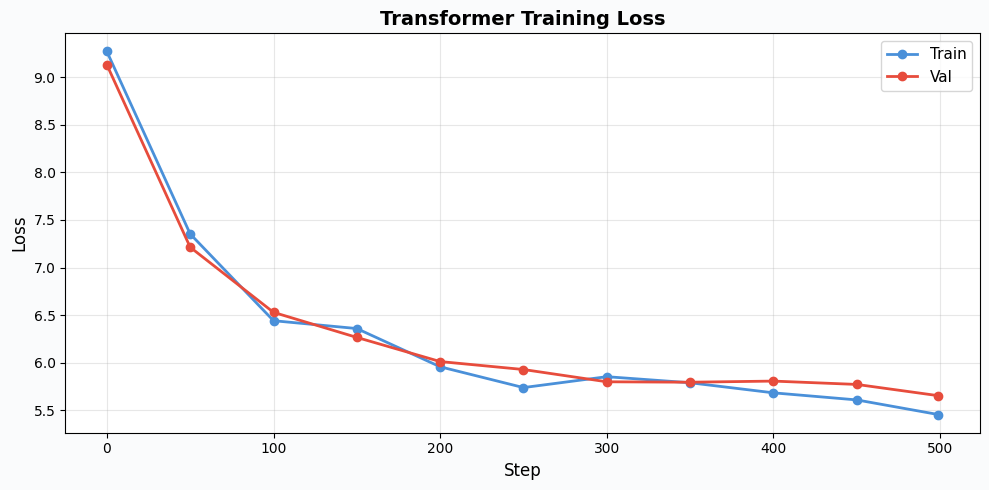

In [34]:
plt.figure(figsize=(10, 5), facecolor='#FAFBFC')
plt.plot(steps_log, train_losses, 'o-', color='#4A90D9', label='Train', linewidth=2)
plt.plot(steps_log, val_losses, 'o-', color='#E74C3C', label='Val', linewidth=2)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Transformer Training Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Generating Text

This is where everything comes together. Autoregressive generation works by feeding a prompt into the model, running a forward pass to get logits for the next token, sampling from the distribution, appending the sampled token, and repeating.

Temperature controls the randomness: temperature = 1.0 gives the raw probability distribution, lower temperatures (like 0.8) make the model more confident (sharper distribution, more predictable text), while higher temperatures make it more creative (flatter distribution, more surprising word choices).

The generated text won't be Shakespeare, but with a tiny model trained for just a few hundred steps, the fact that it produces anything coherent at all is a testament to the power of the attention mechanism.

In [35]:
def generate(model, tokenizer, prompt, max_new_tokens=50, temperature=0.8):
  """Generate text autoregressively."""
  ids = tokenizer.encode(prompt)
  model.eval()

  for _ in range(max_new_tokens):
      # Only use last SEQ_LEN tokens if context is too long
      context = ids[-SEQ_LEN:]
      idx = Tensor(np.array([context]))

      logits = model(idx)  # (1, T, vocab_size)
      # Get logits for the last position
      next_logits = logits.data[0, -1, :]  # (vocab_size,)

      # Temperature scaling
      next_logits = next_logits / temperature

      # Softmax to probabilities (move to numpy for sampling)
      logits_np = np.array(next_logits.get()) if hasattr(next_logits, 'get') else np.array(next_logits)
      probs = np.exp(logits_np - logits_np.max())
      probs = probs / probs.sum()

      # Sample
      next_id = np.random.choice(len(probs), p=probs)
      ids.append(int(next_id))

  model.train()
  return tokenizer.decode(ids)

# Generate from different prompts
prompts = [
  'the king',
  'to be or',
  'what is',
  'i shall',
]

print('='*60)
print('GENERATED TEXT')
print('='*60)
for prompt in prompts:
  text = generate(model, tokenizer, prompt, max_new_tokens=30)
  print(f'\nPrompt: "{prompt}"')
  print(f'Output: {text}')
  print('-'*40)

GENERATED TEXT

Prompt: "the king"
Output: the king where, i have' d:, and in me, all heard my to colour well,' s king you when for all to better richard to
----------------------------------------

Prompt: "to be or"
Output: to be or wise of me for heard say of, good <unk> of call cousin besides by <unk> not be of' d to <unk> of but brothers such, for this
----------------------------------------

Prompt: "what is"
Output: what is:; and' s duke! to ii: tell i that suffer. his benvolio: so sir, the evil now thou' s my must for
----------------------------------------

Prompt: "i shall"
Output: i shall with. but that <unk>! o, i' ll to request, grain that a that romeo and of thou to you, mine. power:!
----------------------------------------


## What We Built in Part 3

Starting from the `Tensor` and `Module` abstractions we built in Parts 1 and 2, we implemented every component of a decoder-only transformer:

- **RoPE (Rotary Position Embeddings)**: Encodes position through rotation, giving the model a sense of token ordering without learned position embeddings.
- **LayerNorm**: Keeps activations well-behaved across deep layers, enabling stable training.
- **Causal Self-Attention**: The core mechanism. Each token attends to all previous tokens through scaled dot-product attention with Q, K, V projections and causal masking.
- **Feed-Forward Network (MLP)**: Expands to 4x dimension, applies GELU, projects back, giving the model nonlinear transformation capacity.
- **Embedding**: Converts token IDs to dense vectors with proper gradient scatter.
- **TransformerBlock**: Pre-norm architecture with residual connections, stacking attention and MLP.
- **GPT**: The full decoder-only language model: embedding → N transformer blocks → layer norm → linear projection to vocabulary.

We trained it on Tiny Shakespeare and generated text. Every single gradient, through attention scores, through RoPE rotations, through layer norms, through the entire depth of the network, was computed by the autograd engine we built from scratch in Part 1.

## Key Takeaways

- **Composition is powerful.** The entire transformer (minus Embedding) has zero custom backward code. Everything composes from ~15 primitive Tensor ops. This is the payoff of building a solid autograd foundation.
- **Attention is a soft dictionary lookup.** Queries ask "what am I looking for?", keys answer "what do I have?", and values provide the information. The dot product + softmax produces a weighted mixture.
- **Scaling by $\sqrt{d_k}$ matters.** Without it, dot products grow with dimension, pushing softmax into saturated regions with vanishing gradients.
- **RoPE encodes relative position through rotation.** Instead of adding position embeddings, it rotates Q and K so the dot product naturally reflects relative position, enabling better length generalization.
- **Pre-norm + residuals enable depth.** LayerNorm before each sublayer keeps activations stable. Residual connections give gradients a highway through the network.
- **The training loop is universal.** Forward, loss, zero_grad, backward, step. The same pattern from linear regression in Part 1, to MNIST in Part 2, to a transformer generating Shakespeare in Part 3.

## The Full Journey

This series started with a question: *what actually happens when we call `loss.backward()`?*

To answer it, we built everything from scratch:
- **Part 1**: A `Tensor` class with automatic differentiation: computation graphs, topological sort, chain rule. Verified with numerical gradient checking.
- **Part 2**: `Module`, `Linear`, `ReLU`, `GELU`, `CrossEntropyLoss`, `Adam`, the building blocks of neural networks. Trained an MLP on MNIST.
- **Part 3**: RoPE, LayerNorm, Multi-Head Causal Self-Attention, Transformer, a complete language model trained on Shakespeare.

From computing $\frac{\partial}{\partial x}(x^2) = 2x$ to generating Shakespeare, every gradient was computed by code we wrote ourselves. No PyTorch, no JAX, just Python, NumPy/CuPy, and the chain rule.

The full code is available in the [simplygrad](https://github.com/mandliya/simplygrad) repository.